# Inference Demo

This notebook demonstrates how to use the trained models for inference on new images.

In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
# Define class names (first 20 classes as example)
CLASS_NAMES = [
    'pink primrose', 'hard-leaved pocket orchid', 'canterbury bells',
    'sweet pea', 'english marigold', 'tiger lily', 'moon orchid',
    'bird of paradise', 'monkshood', 'globe thistle', 'snapdragon',
    "colt's foot", 'king protea', 'spear thistle', 'yellow iris',
    'globe-flower', 'purple coneflower', 'peruvian lily', 'balloon flower',
    'giant white arum lily'
]

# If using all 102 classes, you would need the complete list
print(f"Number of class names available: {len(CLASS_NAMES)}")

Number of class names available: 20


In [3]:
# Load models
def load_model(model_name, num_classes=102):
    if model_name == 'vgg16':
        model = models.vgg16(weights=None)
        model.classifier[6] = nn.Linear(4096, num_classes)
        model.load_state_dict(torch.load('../models/vgg16_flowers102.pth', map_location=device))
    elif model_name == 'resnet50':
        model = models.resnet50(weights=None)
        model.fc = nn.Linear(2048, num_classes)
        model.load_state_dict(torch.load('../models/resnet50_flowers102.pth', map_location=device))
    
    model = model.to(device)
    model.eval()
    return model

vgg16_model = load_model('vgg16')
resnet50_model = load_model('resnet50')
print("Models loaded successfully!")

Models loaded successfully!


In [4]:
# Define preprocessing
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def predict_image(image_path, model, top_k=5):
    """Predict class for a single image"""
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    input_tensor = preprocess(image).unsqueeze(0).to(device)
    
    # Inference
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        top_probs, top_indices = torch.topk(probabilities, top_k)
    
    # Convert to Python types
    top_probs = top_probs.cpu().numpy()
    top_indices = top_indices.cpu().numpy()
    
    return image, top_indices, top_probs

Selected 5 test images for inference


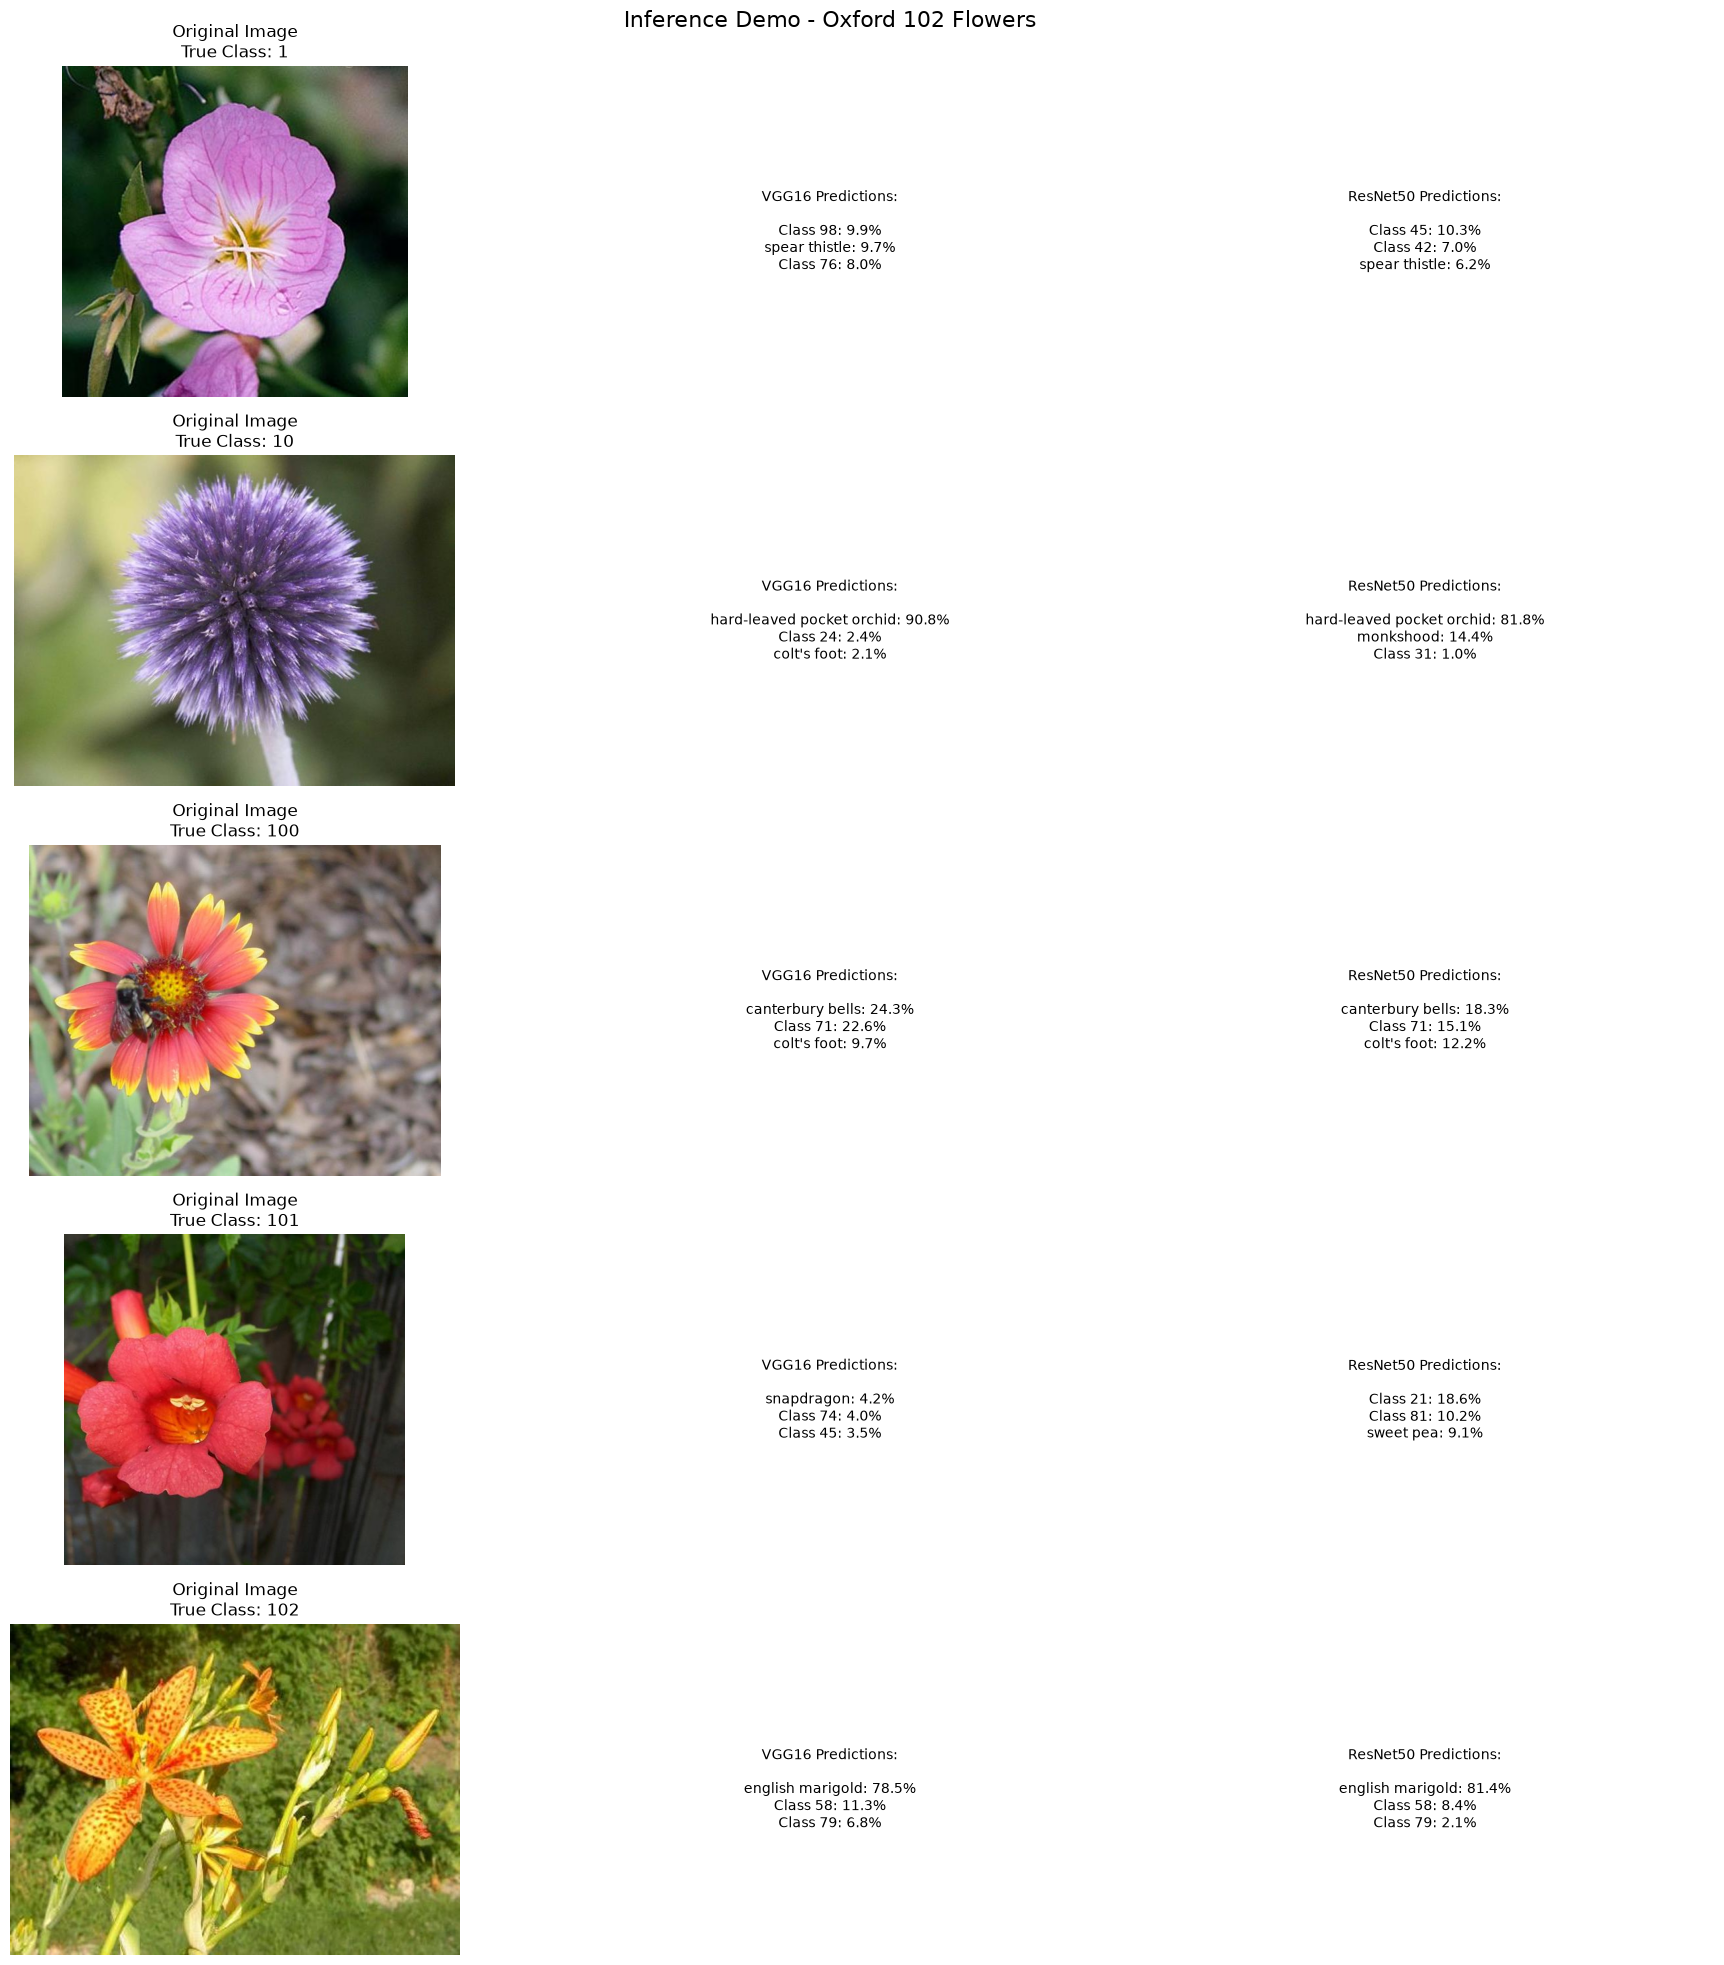

In [5]:
# Test with sample images from test set
test_images_dir = Path('../data/flowers/test')

# Get a few test images
test_images = []
for class_dir in sorted(test_images_dir.iterdir())[:5]:
    if class_dir.is_dir():
        img_path = next(class_dir.glob('*.jpg'))
        test_images.append((img_path, int(class_dir.name)))

print(f"Selected {len(test_images)} test images for inference")

# Run inference on each image with both models
fig, axes = plt.subplots(len(test_images), 3, figsize=(18, 4*len(test_images)))

for idx, (img_path, true_class) in enumerate(test_images):
    # Display original image
    original_img = Image.open(img_path)
    axes[idx, 0].imshow(original_img)
    axes[idx, 0].set_title(f'Original Image\nTrue Class: {true_class}')
    axes[idx, 0].axis('off')
    
    # VGG16 predictions
    _, vgg_indices, vgg_probs = predict_image(img_path, vgg16_model, top_k=3)
    vgg_labels = [CLASS_NAMES[i] if i < len(CLASS_NAMES) else f'Class {i}' for i in vgg_indices]
    vgg_text = '\n'.join([f'{label}: {prob*100:.1f}%' for label, prob in zip(vgg_labels, vgg_probs)])
    axes[idx, 1].text(0.5, 0.5, f'VGG16 Predictions:\n\n{vgg_text}', 
                     ha='center', va='center', fontsize=10, transform=axes[idx, 1].transAxes)
    axes[idx, 1].axis('off')
    
    # ResNet50 predictions
    _, resnet_indices, resnet_probs = predict_image(img_path, resnet50_model, top_k=3)
    resnet_labels = [CLASS_NAMES[i] if i < len(CLASS_NAMES) else f'Class {i}' for i in resnet_indices]
    resnet_text = '\n'.join([f'{label}: {prob*100:.1f}%' for label, prob in zip(resnet_labels, resnet_probs)])
    axes[idx, 2].text(0.5, 0.5, f'ResNet50 Predictions:\n\n{resnet_text}', 
                     ha='center', va='center', fontsize=10, transform=axes[idx, 2].transAxes)
    axes[idx, 2].axis('off')

plt.suptitle('Inference Demo - Oxford 102 Flowers', fontsize=16)
plt.tight_layout()
plt.show()

In [6]:
# Test with a custom image
def test_custom_image(image_path):
    """Test model on a custom image"""
    if not Path(image_path).exists():
        print(f"Image not found: {image_path}")
        return
    
    print(f"Analyzing image: {image_path}")
    print("-" * 40)
    
    for model_name, model in [('VGG16', vgg16_model), ('ResNet50', resnet50_model)]:
        image, indices, probs = predict_image(image_path, model, top_k=3)
        print(f"\n{model_name} Top-3 Predictions:")
        for i, (idx, prob) in enumerate(zip(indices, probs)):
            class_name = CLASS_NAMES[idx] if idx < len(CLASS_NAMES) else f'Class {idx}'
            print(f"  {i+1}. {class_name}: {prob*100:.2f}%")
    
    # Display image
    plt.figure(figsize=(8, 8))
    plt.imshow(Image.open(image_path))
    plt.axis('off')
    plt.title('Test Image')
    plt.show()

# Example usage (uncomment and provide your image path)
# test_custom_image('../data/raw/jpg/image_0001.jpg')

In [7]:
# Batch inference performance test
import time

def benchmark_inference(model, num_images=100):
    """Benchmark inference speed"""
    model.eval()
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    
    # Warm-up
    for _ in range(10):
        with torch.no_grad():
            model(dummy_input)
    
    # Benchmark
    start_time = time.time()
    for _ in range(num_images):
        with torch.no_grad():
            model(dummy_input)
    end_time = time.time()
    
    avg_time = (end_time - start_time) / num_images
    return avg_time

vgg16_time = benchmark_inference(vgg16_model)
resnet50_time = benchmark_inference(resnet50_model)

print(f"VGG16 Average inference time: {vgg16_time*1000:.2f} ms/image")
print(f"ResNet50 Average inference time: {resnet50_time*1000:.2f} ms/image")
print(f"\nResNet50 is {vgg16_time/resnet50_time:.2f}x faster than VGG16")

VGG16 Average inference time: 629.87 ms/image
ResNet50 Average inference time: 217.33 ms/image

ResNet50 is 2.90x faster than VGG16
